In [5]:
import sys
sys.path.append("..")

from src.data_cleaning import check_data_types, check_missing_values, add_daily_return
from src.eda import summary_statistics, rolling_mean_std, detect_outliers
from src.stationarity import adf_test
from src.risk_metrics import value_at_risk, sharpe_ratio

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

tickers = ["TSLA", "BND", "SPY"]
data = {}

for ticker in tickers:
    df = pd.read_csv(f"../data/processed/{ticker}.csv", index_col="Date", parse_dates=True)
    data[ticker] = df

# Quick look at TSLA
data["TSLA"].head()

,Close,High,Low,Open,Volume
Date,,,,,
2015-01-02,14.620667,14.883333,14.217333,14.858000,71466000
2015-01-05,14.006000,14.433333,13.810667,14.303333,80527500
2015-01-06,14.085333,14.280000,13.614000,14.004000,93928500
2015-01-07,14.063333,14.318667,13.985333,14.223333,44526000
2015-01-08,14.041333,14.253333,14.000667,14.187333,51637500


In [7]:
for ticker in tickers:
    print(f"--- {ticker} dtypes ---")
    print(data[ticker].dtypes)
    print()

--- TSLA dtypes ---
Close     float64
High      float64
Low       float64
Open      float64
Volume      int64
dtype: object

--- BND dtypes ---
Close     float64
High      float64
Low       float64
Open      float64
Volume      int64
dtype: object

--- SPY dtypes ---
Close     float64
High      float64
Low       float64
Open      float64
Volume      int64
dtype: object



In [8]:
for ticker in tickers:
    missing = data[ticker].isnull().sum()
    print(f"--- {ticker} missing values ---")
    print(missing[missing > 0] if missing.sum() > 0 else "No missing values")
    print()

--- TSLA missing values ---
No missing values

--- BND missing values ---
No missing values

--- SPY missing values ---
No missing values



In [9]:
for ticker in tickers:
    data[ticker] = data[ticker].asfreq("B")  # 'B' = business day frequency
    data[ticker] = data[ticker].ffill()      # forward-fill: carry last known price forward

In [10]:
for ticker in tickers:
    print(f"--- {ticker} summary statistics ---")
    print(data[ticker].describe())
    print()

--- TSLA summary statistics ---
             Close         High          Low         Open        Volume
count  2997.000000  2997.000000  2997.000000  2997.000000  2.997000e+03
mean    149.169212   152.376992   145.806181   149.175964  1.085856e+08
std     139.205179   142.152215   136.176395   139.273348  7.043410e+07
min       9.578000    10.331333     9.403333     9.488000  1.062000e+07
25%      18.439333    18.688667    18.169333    18.460667  6.551900e+07
50%     133.455338   136.243332   125.293335   131.659332  8.986950e+07
75%     252.080002   257.790009   246.179993   252.039993  1.259700e+08
max     489.880005   498.829987   485.329987   489.880005  9.140820e+08

--- BND summary statistics ---
             Close         High          Low         Open        Volume
count  2997.000000  2997.000000  2997.000000  2997.000000  2.997000e+03
mean     66.504812    66.601576    66.406087    66.506925  4.635442e+06
std       4.709631     4.715787     4.701744     4.709001  2.998625e+06


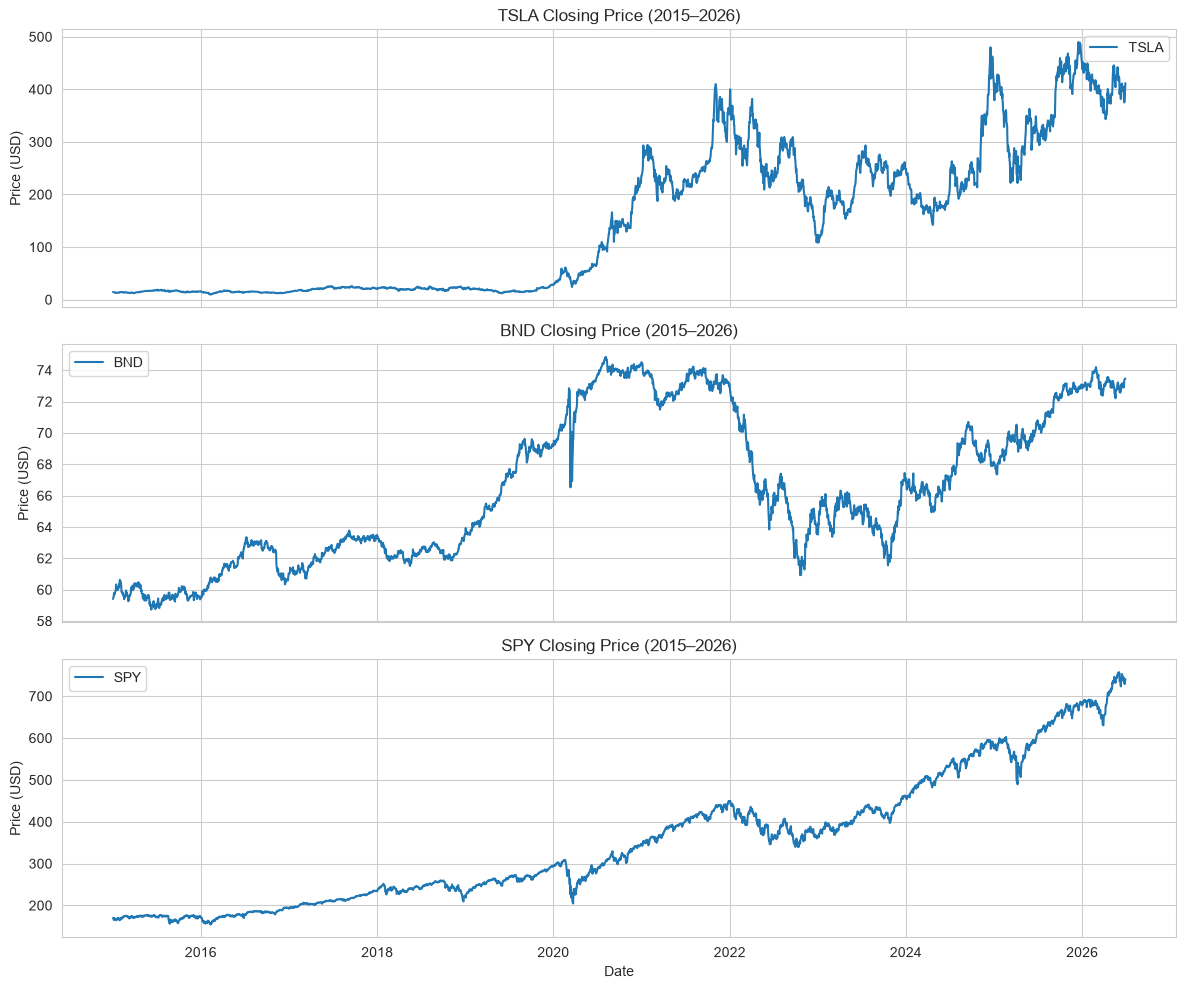

In [11]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

for ax, ticker in zip(axes, tickers):
    ax.plot(data[ticker].index, data[ticker]["Close"], label=ticker)
    ax.set_title(f"{ticker} Closing Price (2015–2026)")
    ax.set_ylabel("Price (USD)")
    ax.legend()

plt.xlabel("Date")
plt.tight_layout()
plt.savefig("../data/processed/closing_prices.png", dpi=150)
plt.show()

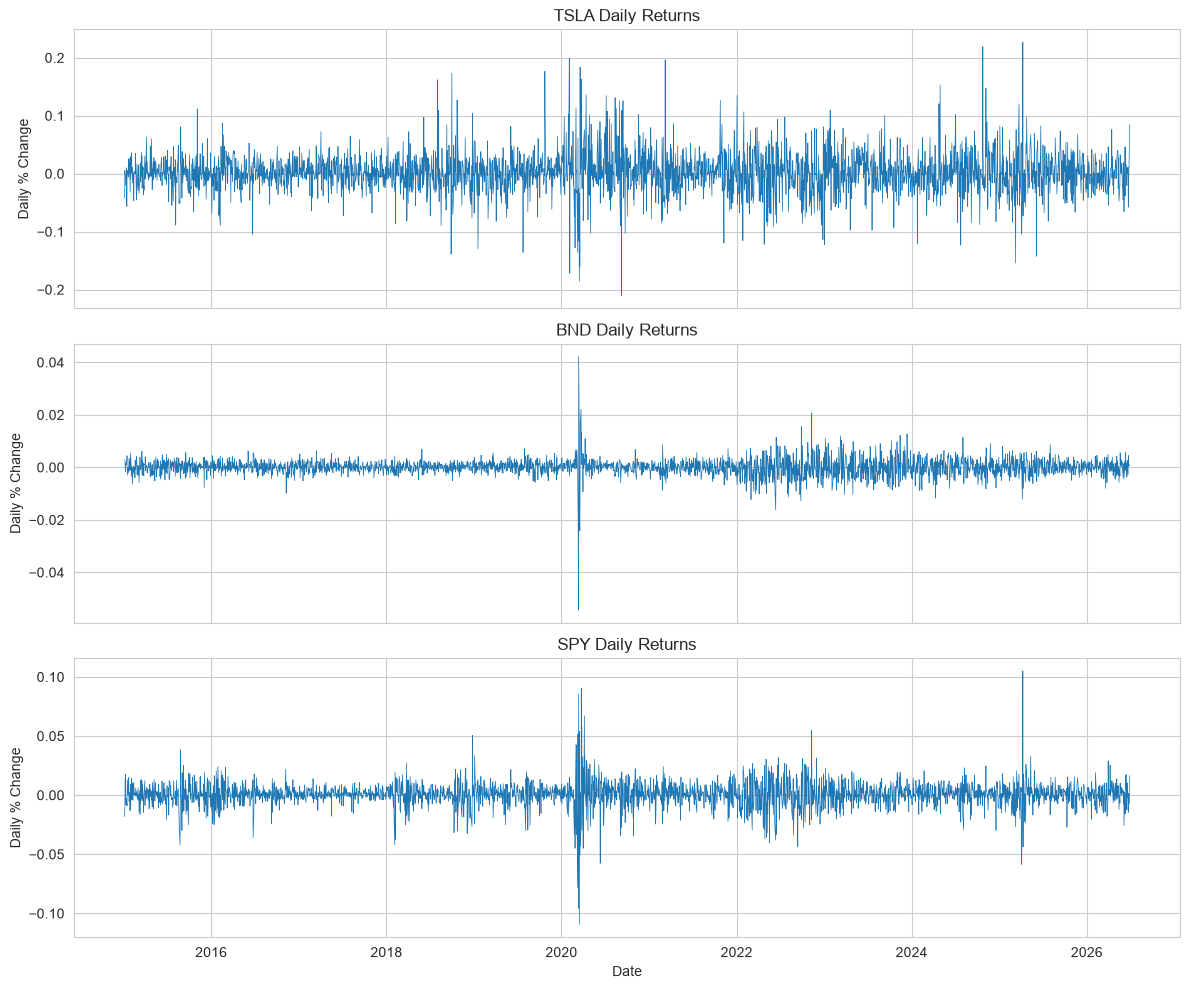

In [12]:
returns = {}

for ticker in tickers:
    returns[ticker] = data[ticker]["Close"].pct_change()
    data[ticker]["Daily Return"] = returns[ticker]

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

for ax, ticker in zip(axes, tickers):
    ax.plot(data[ticker].index, data[ticker]["Daily Return"], linewidth=0.5)
    ax.set_title(f"{ticker} Daily Returns")
    ax.set_ylabel("Daily % Change")

plt.xlabel("Date")
plt.tight_layout()
plt.savefig("../data/processed/daily_returns.png", dpi=150)
plt.show()

In [13]:
for ticker in tickers:
    print(f"--- {ticker} ---")

    outliers = detect_outliers(data[ticker])
    print(f"Outliers detected: {len(outliers)}")

    adf_result = adf_test(data[ticker]["Close"])
    print(f"ADF (Close) p-value: {adf_result['p_value']:.4f}, stationary: {adf_result['is_stationary']}")

    var = value_at_risk(data[ticker]["Daily Return"])
    sharpe = sharpe_ratio(data[ticker]["Daily Return"])
    print(f"VaR (95%): {var:.4%}, Sharpe Ratio: {sharpe:.4f}")
    print()

--- TSLA ---
Outliers detected: 50
ADF (Close) p-value: 0.7389, stationary: False
VaR (95%): -5.1096%, Sharpe Ratio: 0.7442

--- BND ---
Outliers detected: 35
ADF (Close) p-value: 0.7084, stationary: False
VaR (95%): -0.4724%, Sharpe Ratio: -0.0147

--- SPY ---
Outliers detected: 42
ADF (Close) p-value: 0.9973, stationary: False
VaR (95%): -1.6354%, Sharpe Ratio: 0.6870



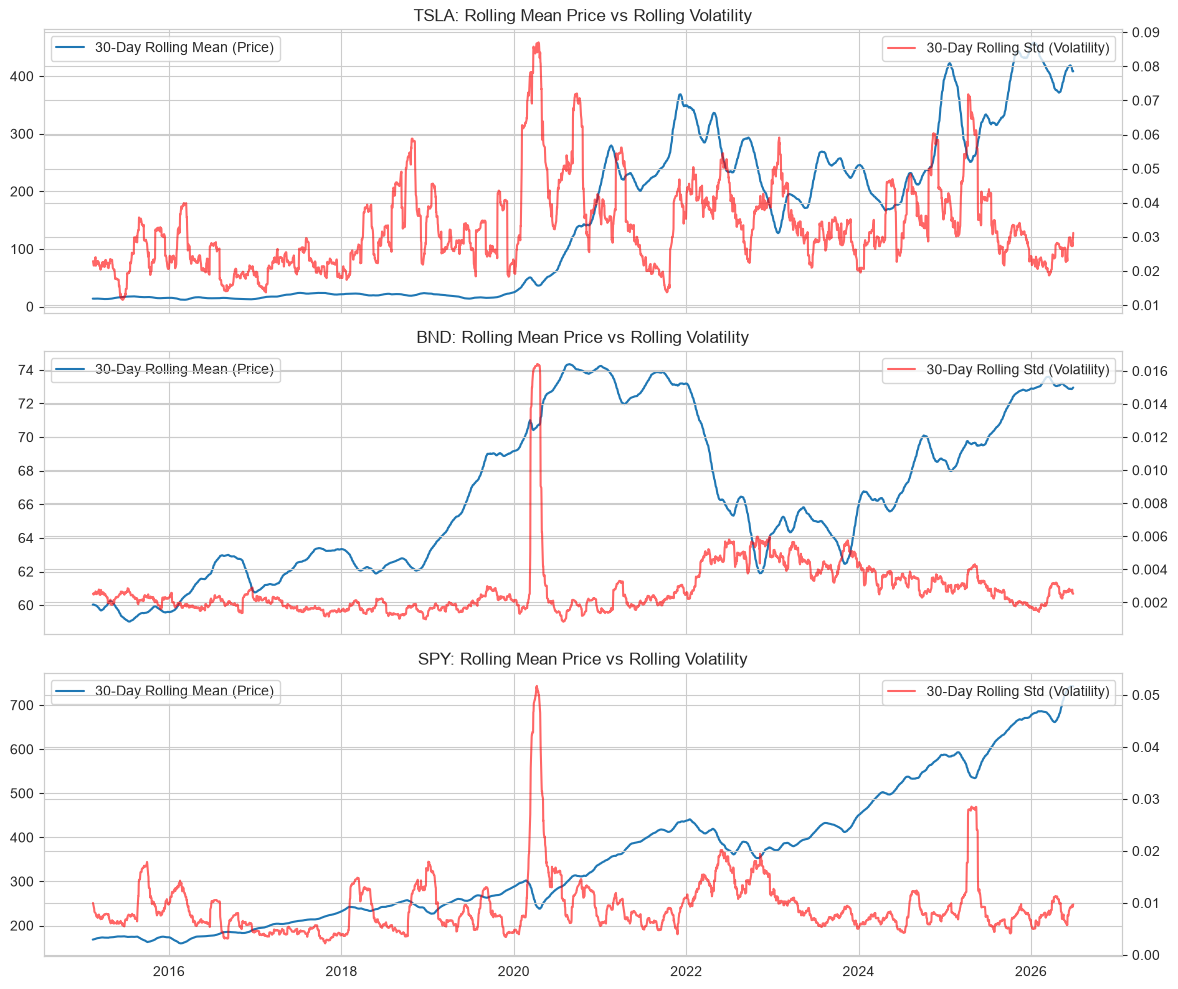

In [14]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

for ax, ticker in zip(axes, tickers):
    rolling_mean = data[ticker]["Close"].rolling(window=30).mean()
    rolling_std = data[ticker]["Daily Return"].rolling(window=30).std()

    ax.plot(data[ticker].index, rolling_mean, label="30-Day Rolling Mean (Price)")
    ax2 = ax.twinx()
    ax2.plot(data[ticker].index, rolling_std, color="red", alpha=0.6, label="30-Day Rolling Std (Volatility)")

    ax.set_title(f"{ticker}: Rolling Mean Price vs Rolling Volatility")
    ax.legend(loc="upper left")
    ax2.legend(loc="upper right")

plt.xlabel("Date")
plt.tight_layout()
plt.savefig("../data/processed/rolling_volatility.png", dpi=150)
plt.show()

In [15]:
for ticker in tickers:
    ret = data[ticker]["Daily Return"].dropna()
    mean, std = ret.mean(), ret.std()

    # Flag days where return is more than 3 standard deviations from the mean
    outliers = ret[(ret - mean).abs() > 3 * std]

    print(f"--- {ticker}: {len(outliers)} outlier days (>3 std from mean) ---")
    print(outliers.sort_values().head(5))   # worst days
    print(outliers.sort_values(ascending=False).head(5))  # best days
    print()

--- TSLA: 50 outlier days (>3 std from mean) ---
Date
2020-09-08   -0.210628
2020-03-16   -0.185778
2020-02-05   -0.171758
2020-03-18   -0.160344
2025-03-10   -0.154262
Name: Daily Return, dtype: float64
Date
2025-04-09    0.226900
2024-10-24    0.219190
2020-02-03    0.198949
2021-03-09    0.196412
2020-03-19    0.183877
Name: Daily Return, dtype: float64

--- BND: 35 outlier days (>3 std from mean) ---
Date
2020-03-12   -0.054385
2020-03-18   -0.024140
2020-03-17   -0.020686
2020-03-11   -0.018940
2022-06-13   -0.016152
Name: Daily Return, dtype: float64
Date
2020-03-13    0.042201
2020-03-23    0.022149
2022-11-10    0.020702
2020-03-20    0.016955
2022-09-28    0.015543
Name: Daily Return, dtype: float64

--- SPY: 42 outlier days (>3 std from mean) ---
Date
2020-03-16   -0.109424
2020-03-12   -0.095677
2020-03-09   -0.078095
2025-04-04   -0.058543
2020-06-11   -0.057649
Name: Daily Return, dtype: float64
Date
2025-04-09    0.105019
2020-03-24    0.090603
2020-03-13    0.085487
2020

In [16]:
from statsmodels.tsa.stattools import adfuller

def run_adf_test(series, label):
    series = series.dropna()
    result = adfuller(series)
    print(f"--- ADF Test: {label} ---")
    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"p-value: {result[1]:.4f}")
    print("Critical Values:")
    for key, value in result[4].items():
        print(f"   {key}: {value:.4f}")
    conclusion = "STATIONARY" if result[1] < 0.05 else "NON-STATIONARY"
    print(f"Conclusion: {conclusion} (using 5% significance level)")
    print()

for ticker in tickers:
    run_adf_test(data[ticker]["Close"], f"{ticker} Closing Price")
    run_adf_test(data[ticker]["Daily Return"], f"{ticker} Daily Return")

--- ADF Test: TSLA Closing Price ---
ADF Statistic: -1.0387
p-value: 0.7389
Critical Values:
   1%: -3.4326
   5%: -2.8625
   10%: -2.5673
Conclusion: NON-STATIONARY (using 5% significance level)

--- ADF Test: TSLA Daily Return ---
ADF Statistic: -55.1498
p-value: 0.0000
Critical Values:
   1%: -3.4325
   5%: -2.8625
   10%: -2.5673
Conclusion: STATIONARY (using 5% significance level)

--- ADF Test: BND Closing Price ---
ADF Statistic: -1.1166
p-value: 0.7084
Critical Values:
   1%: -3.4325
   5%: -2.8625
   10%: -2.5673
Conclusion: NON-STATIONARY (using 5% significance level)

--- ADF Test: BND Daily Return ---
ADF Statistic: -21.2770
p-value: 0.0000
Critical Values:
   1%: -3.4325
   5%: -2.8625
   10%: -2.5673
Conclusion: STATIONARY (using 5% significance level)

--- ADF Test: SPY Closing Price ---
ADF Statistic: 1.4333
p-value: 0.9973
Critical Values:
   1%: -3.4326
   5%: -2.8625
   10%: -2.5673
Conclusion: NON-STATIONARY (using 5% significance level)

--- ADF Test: SPY Daily Ret

In [17]:
risk_free_rate = 0.02  # annualized risk-free rate assumption (e.g., ~2% T-bill yield)

print(f"{'Ticker':<8}{'VaR (95%)':<15}{'Sharpe Ratio':<15}")
print("-" * 38)

for ticker in tickers:
    daily_ret = data[ticker]["Daily Return"].dropna()

    # Historical VaR at 95% confidence: the 5th percentile of daily returns.
    # Interpretation: "on the worst 5% of days, you can expect to lose at least this much."
    var_95 = np.percentile(daily_ret, 5)

    # Sharpe Ratio: excess return per unit of risk, annualized.
    # (mean daily return - daily risk-free rate) / daily std, scaled by sqrt(252) trading days.
    daily_rf = risk_free_rate / 252
    sharpe_ratio = (daily_ret.mean() - daily_rf) / daily_ret.std() * np.sqrt(252)

    print(f"{ticker:<8}{var_95:<15.4%}{sharpe_ratio:<15.4f}")

Ticker  VaR (95%)      Sharpe Ratio   
--------------------------------------
TSLA    -5.1096%       0.7442         
BND     -0.4724%       -0.0147        
SPY     -1.6354%       0.6870         
